# Xử lý graph kết quả 

## Thư viện cần thiết

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Truyền dữ liệu từ V-Experiment Results

Lấy từng ticket ứng với từng folder trong kết quả đã có

In [2]:
# Tìm thư mục dữ liệu dù notebook được chạy từ JOURNAL_2026 hay từ thư mục gốc dự án.
def find_results_dir(start: Path) -> Path:
    start = start.resolve()
    relative_locations = (
        Path('V-Experiment Results'),
        Path('application/JOURNAL_2026/V-Experiment Results'),
    )
    for parent in (start, *start.parents):
        for relative in relative_locations:
            candidate = parent / relative
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError('Không tìm thấy thư mục V-Experiment Results.')


RESULTS_DIR = find_results_dir(Path.cwd())
SCENARIOS = ('bad', 'good')

# Mỗi thư mục cấp một là một ticker; chỉ nhận ticker có đủ hai file tổng hợp bad/good.
summary_files = {}
for ticker_dir in sorted(path for path in RESULTS_DIR.iterdir() if path.is_dir()):
    files = {
        scenario: ticker_dir / scenario / 'three_strategy_summary.csv'
        for scenario in SCENARIOS
    }
    if all(path.is_file() for path in files.values()):
        summary_files[ticker_dir.name] = files

if not summary_files:
    raise FileNotFoundError(
        f'Không tìm thấy file three_strategy_summary.csv trong {RESULTS_DIR}'
    )

frames = []
for ticker, files in summary_files.items():
    for scenario, csv_path in files.items():
        frame = pd.read_csv(csv_path)
        frame['_ticker'] = ticker
        frame['_scenario'] = scenario
        frames.append(frame)

experiment_results = pd.concat(frames, ignore_index=True)
TICKERS = tuple(summary_files)
print(f'Đã nạp {len(frames)} file cho {len(TICKERS)} ticker: {", ".join(TICKERS)}')

Đã nạp 12 file cho 6 ticker: ACB, FPT, GAS, HPG, SSI, VCB


## Vẽ biểu đồ kết quả

Mục tiêu hình vẽ: Vẽ biểu đồ cột cho mỗi độ đo của bài thực nghiệm, lấy từ các ticket ở mỗi folder. Chỉ lấy 6 độ đo chính để trình bày là Profit, ROI %, ARR %, Sharpe Ratio, Max Drawdown, và Violation. Nên để đơn vị đầy đủ cho mỗi độ đo, ví dụ Profit (%), ROI (%), ARR (%), Sharpe Ratio, Max Drawdown (%), Violation (count). Không cần tựa đề cho biểu đồ. Có chia bad và good cho mỗi độ đo, ví dụ Profit (bad) và Profit (good). Mỗi độ đo có 2 cột, một cột cho bad và một cột cho good. Mỗi cột có màu sắc khác nhau để dễ phân biệt. Có in đậm cho các kết quả mà UCB làm tốt hơn so với baseline. Mỗi ticket 1 biểu đồ cột riêng, không tạo thêm file gì hết, chỉ xuất hình plot lên thành output trên notebook.

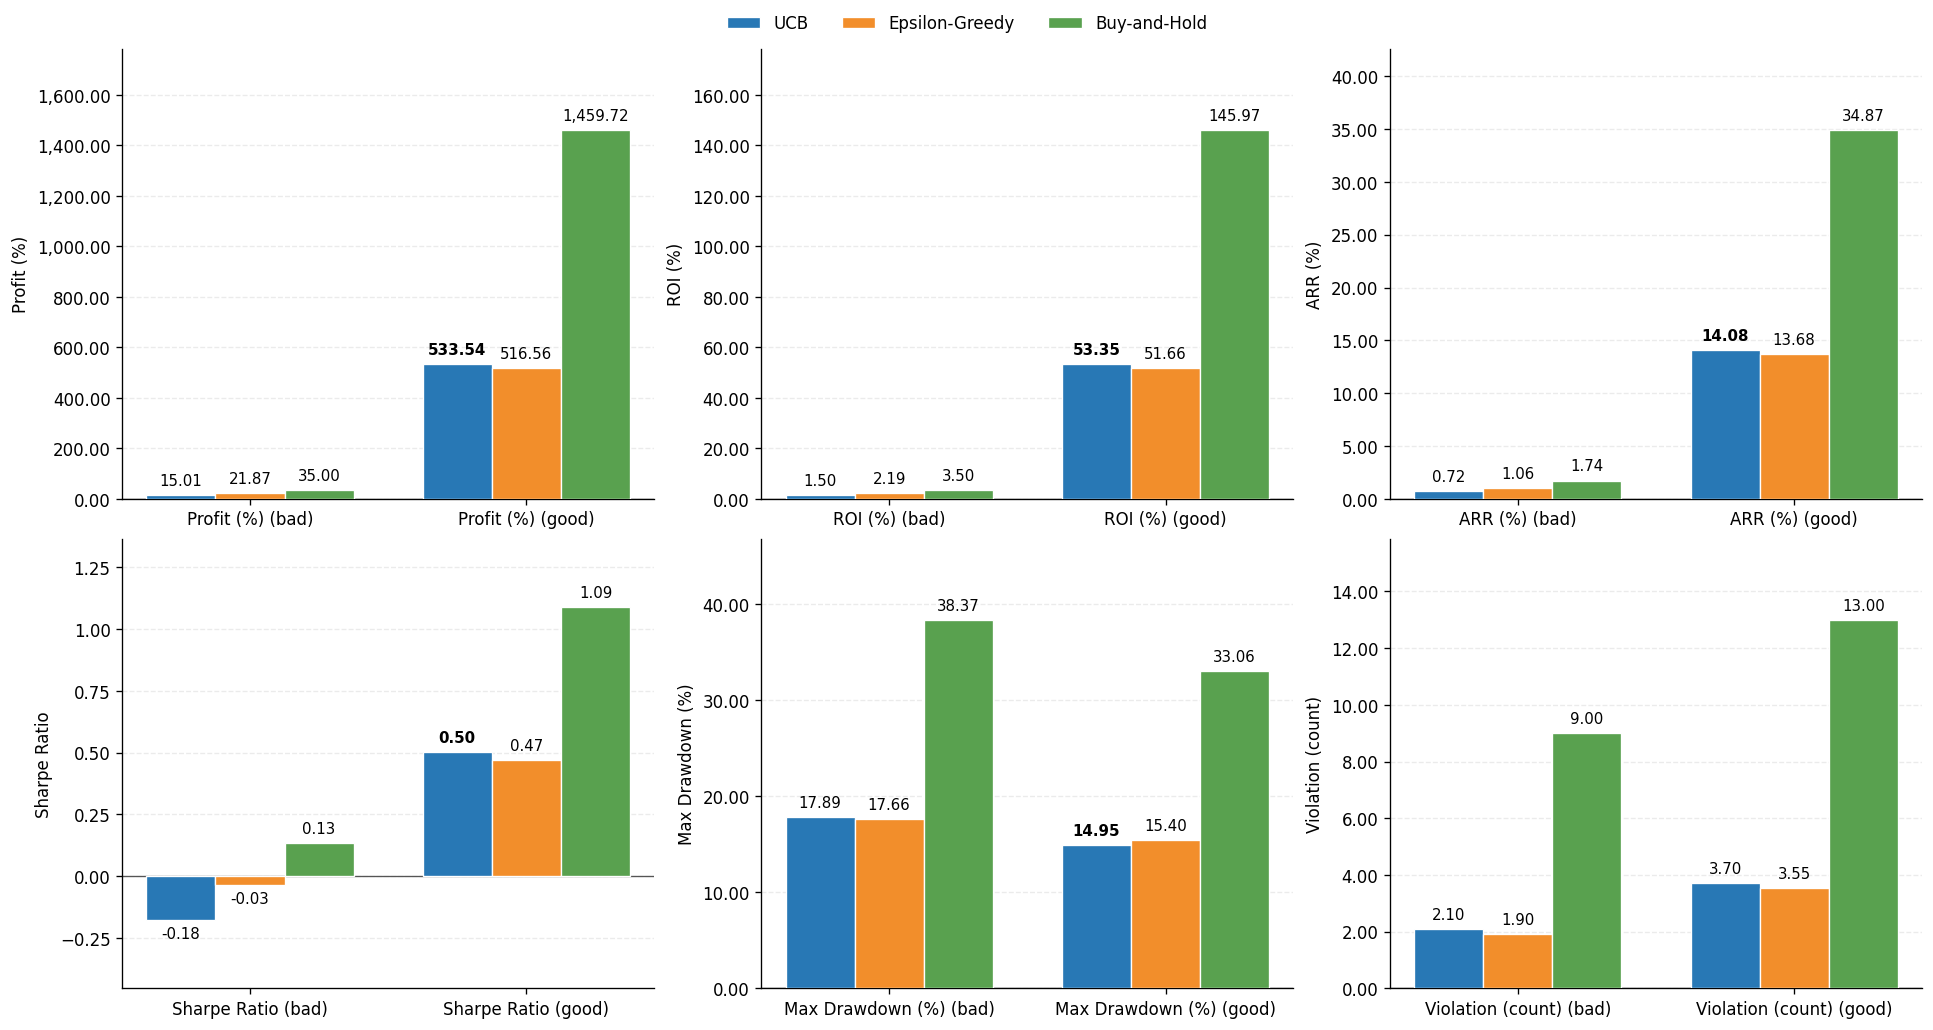

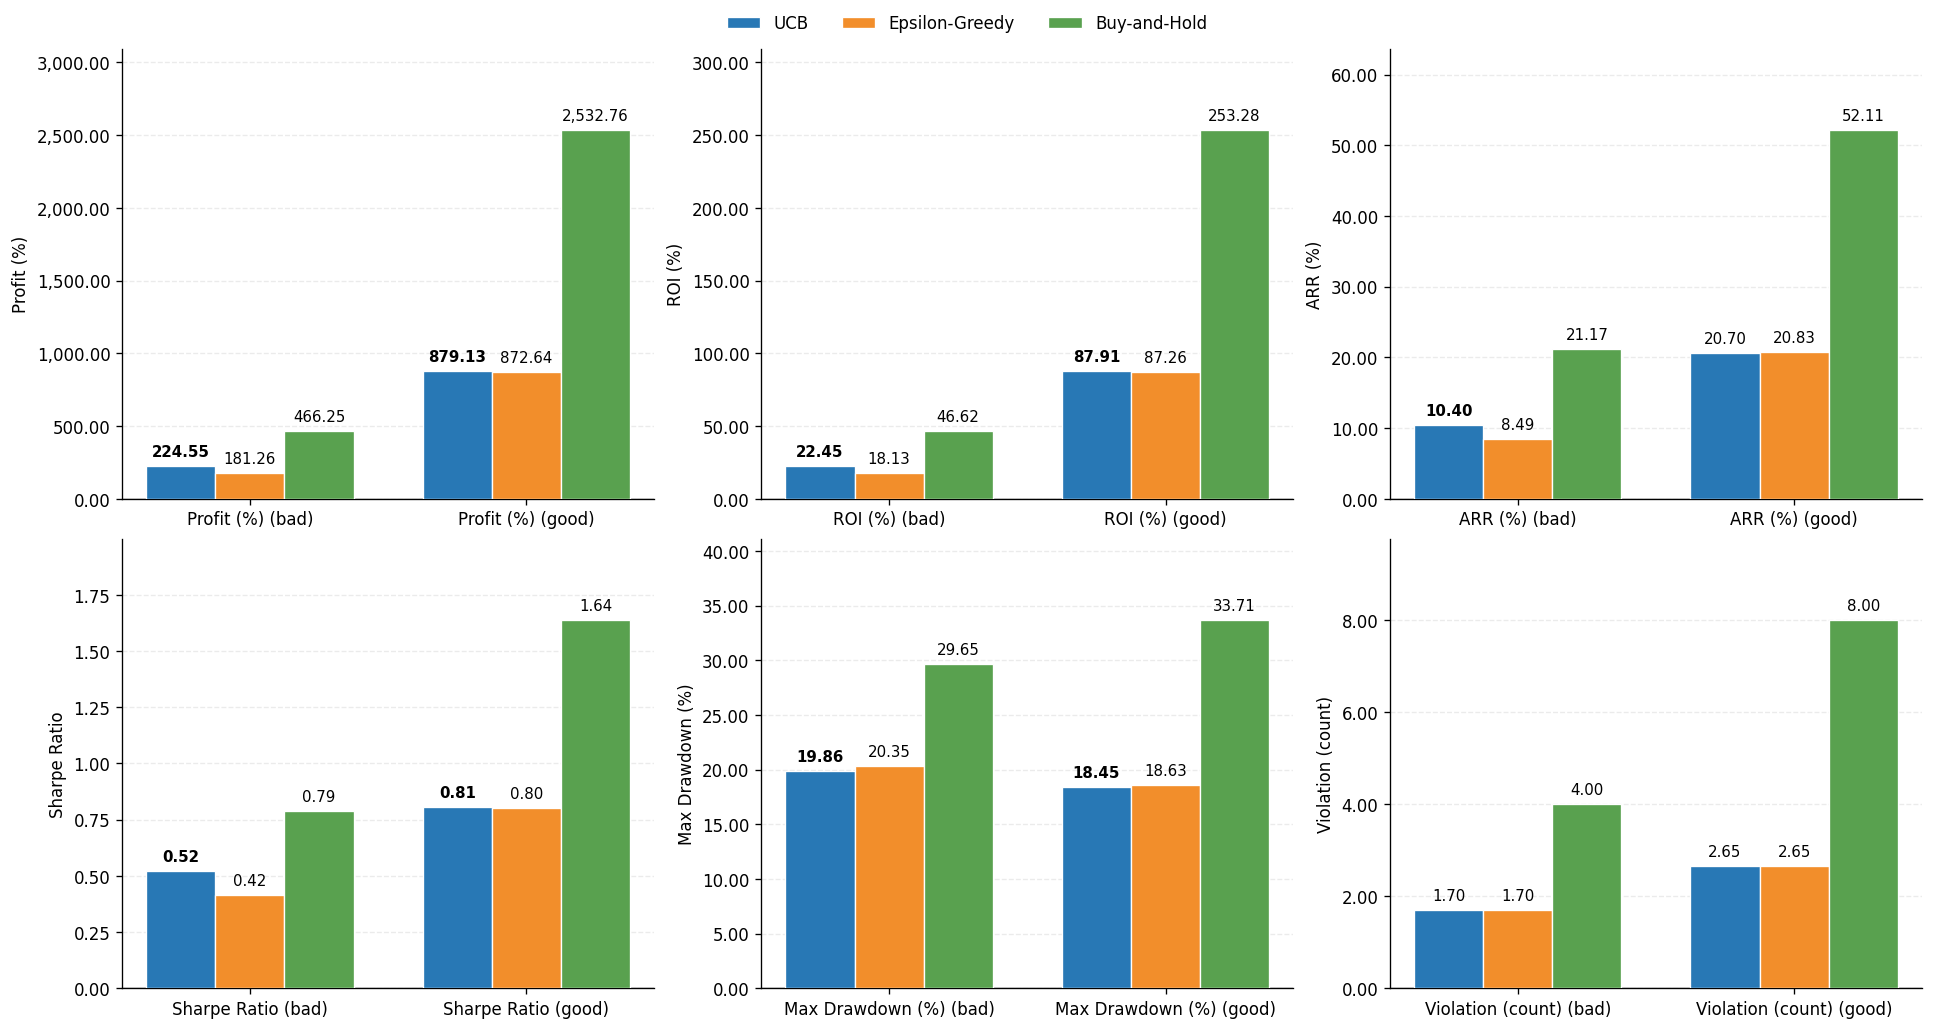

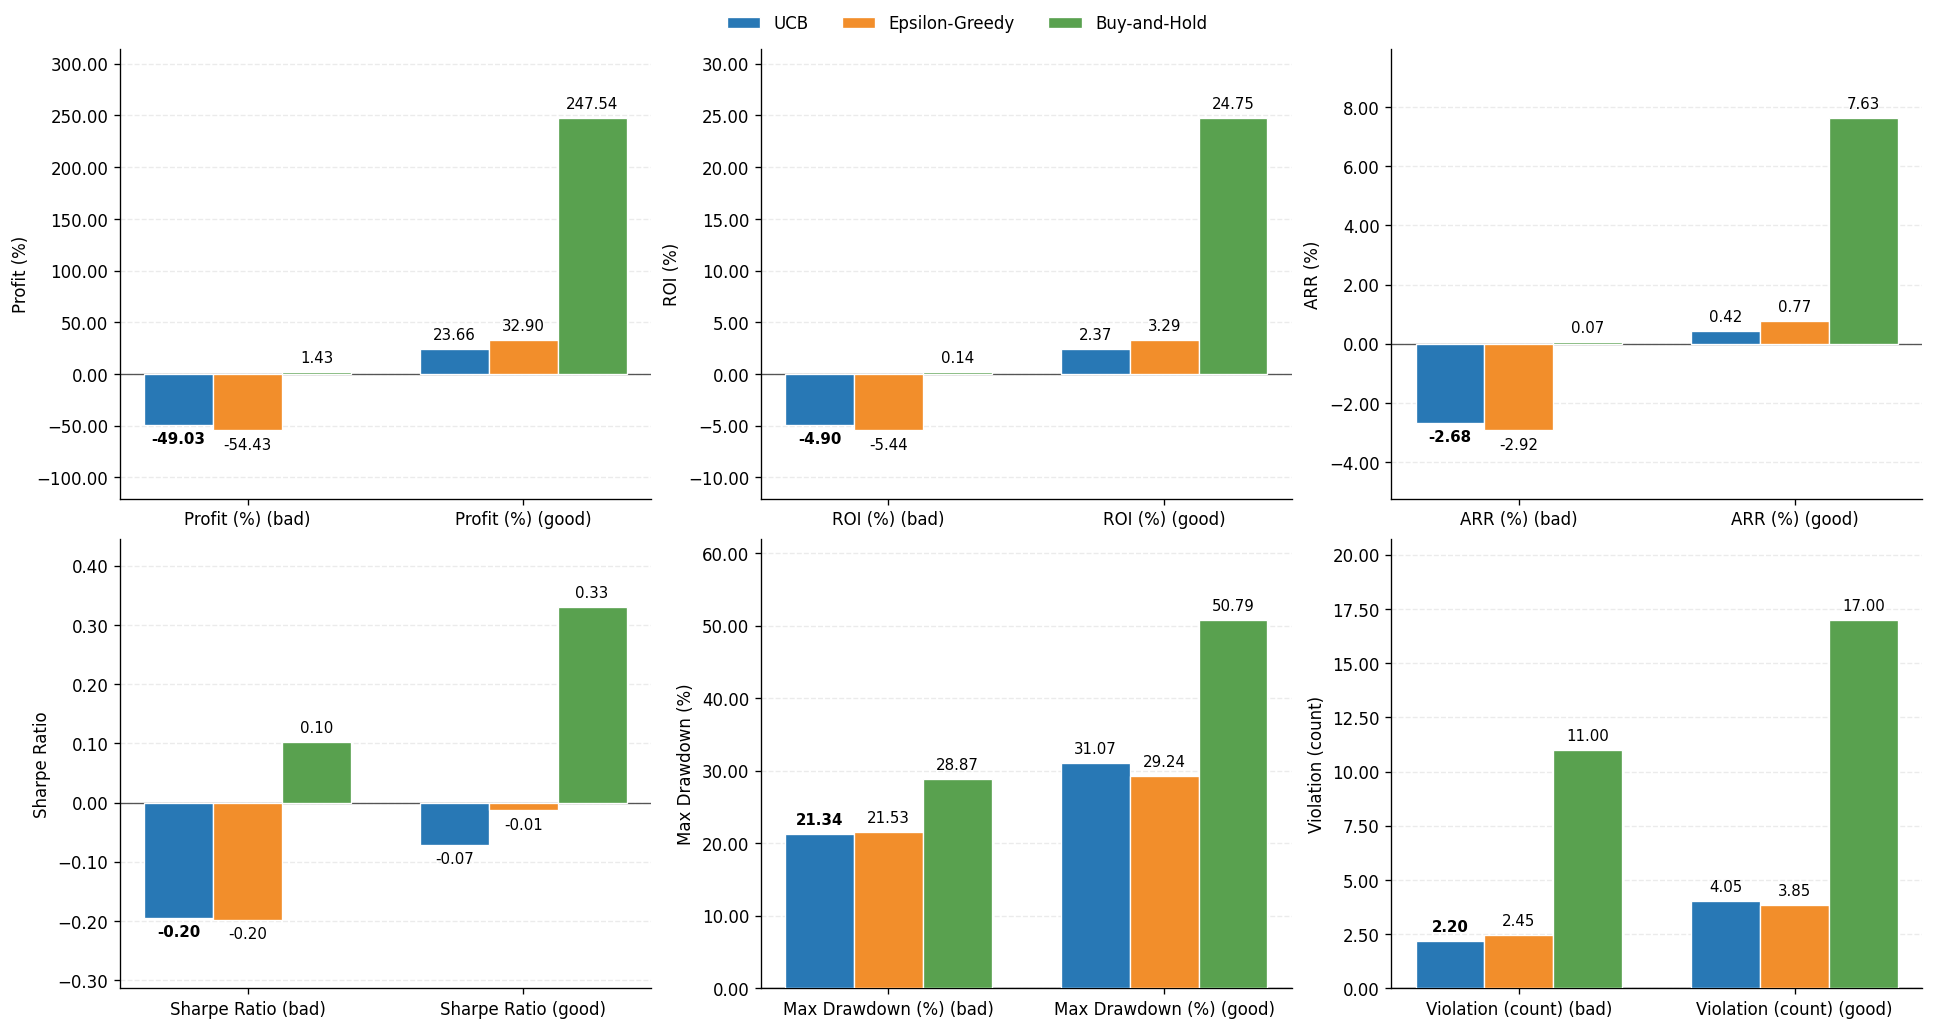

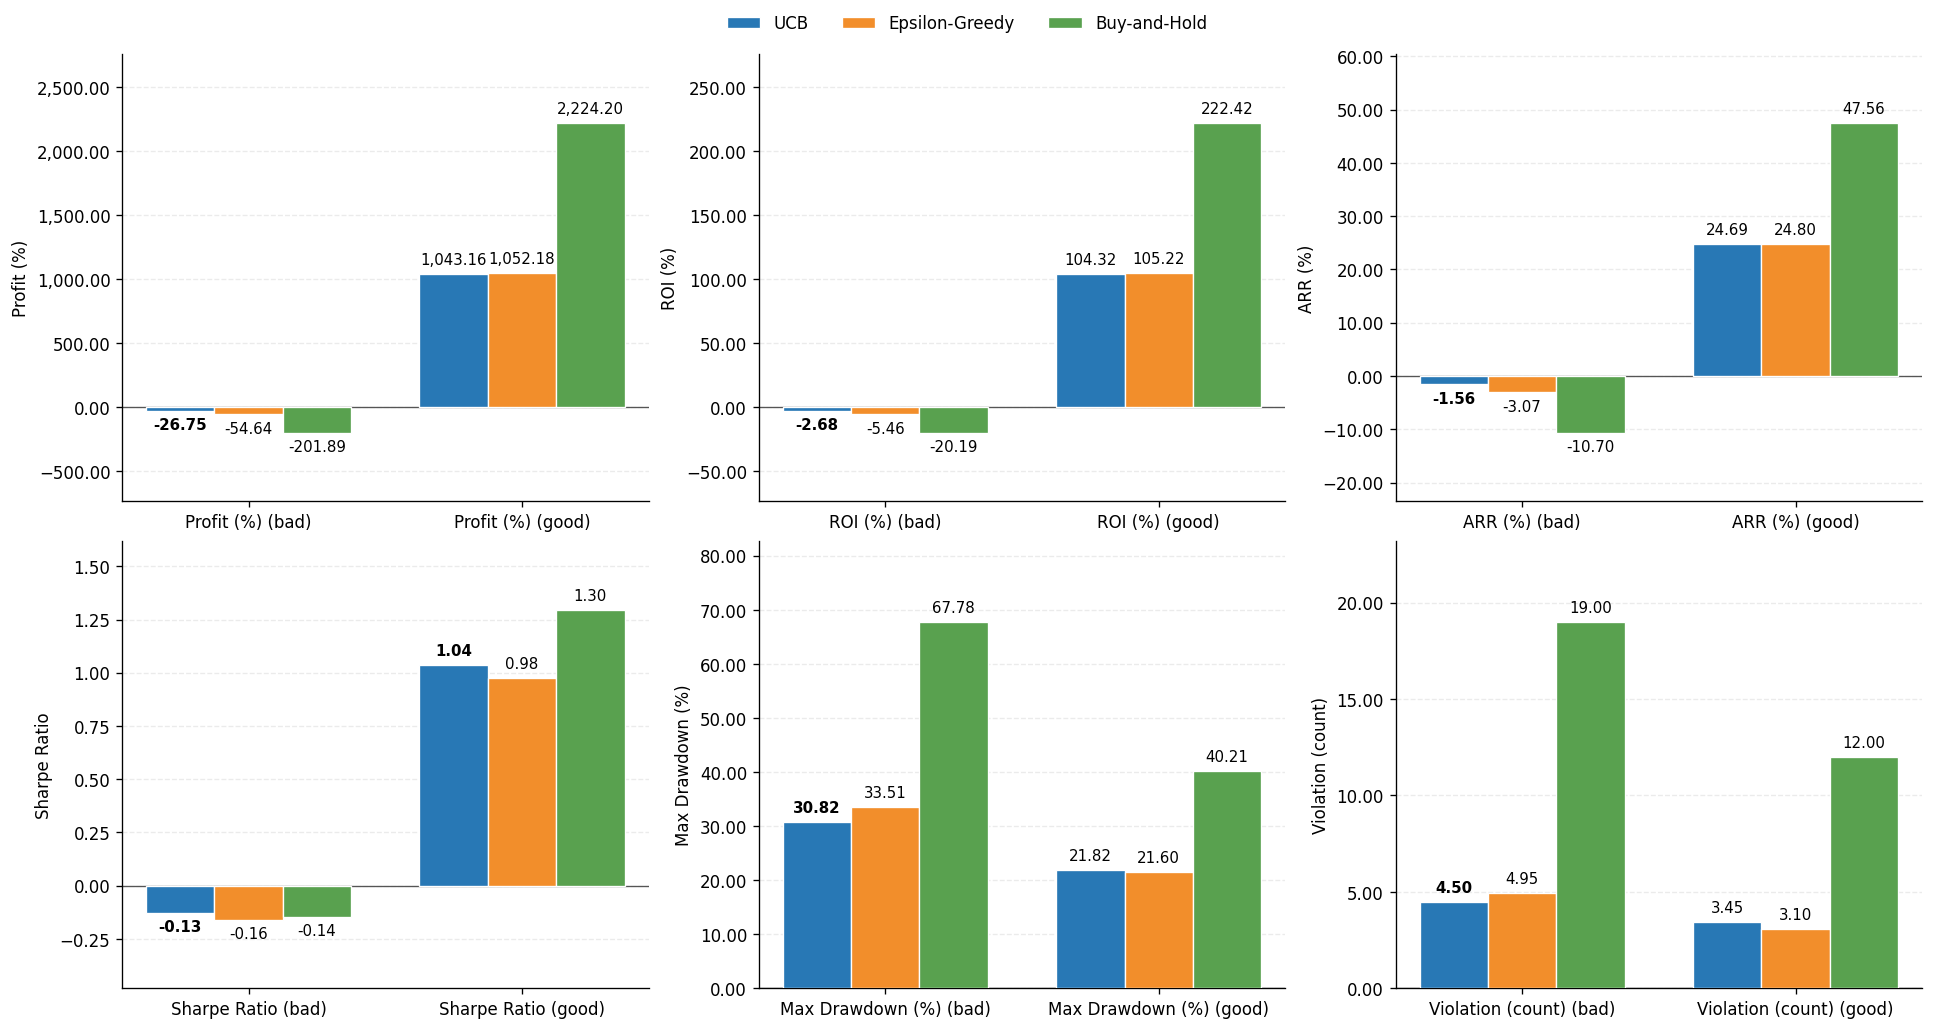

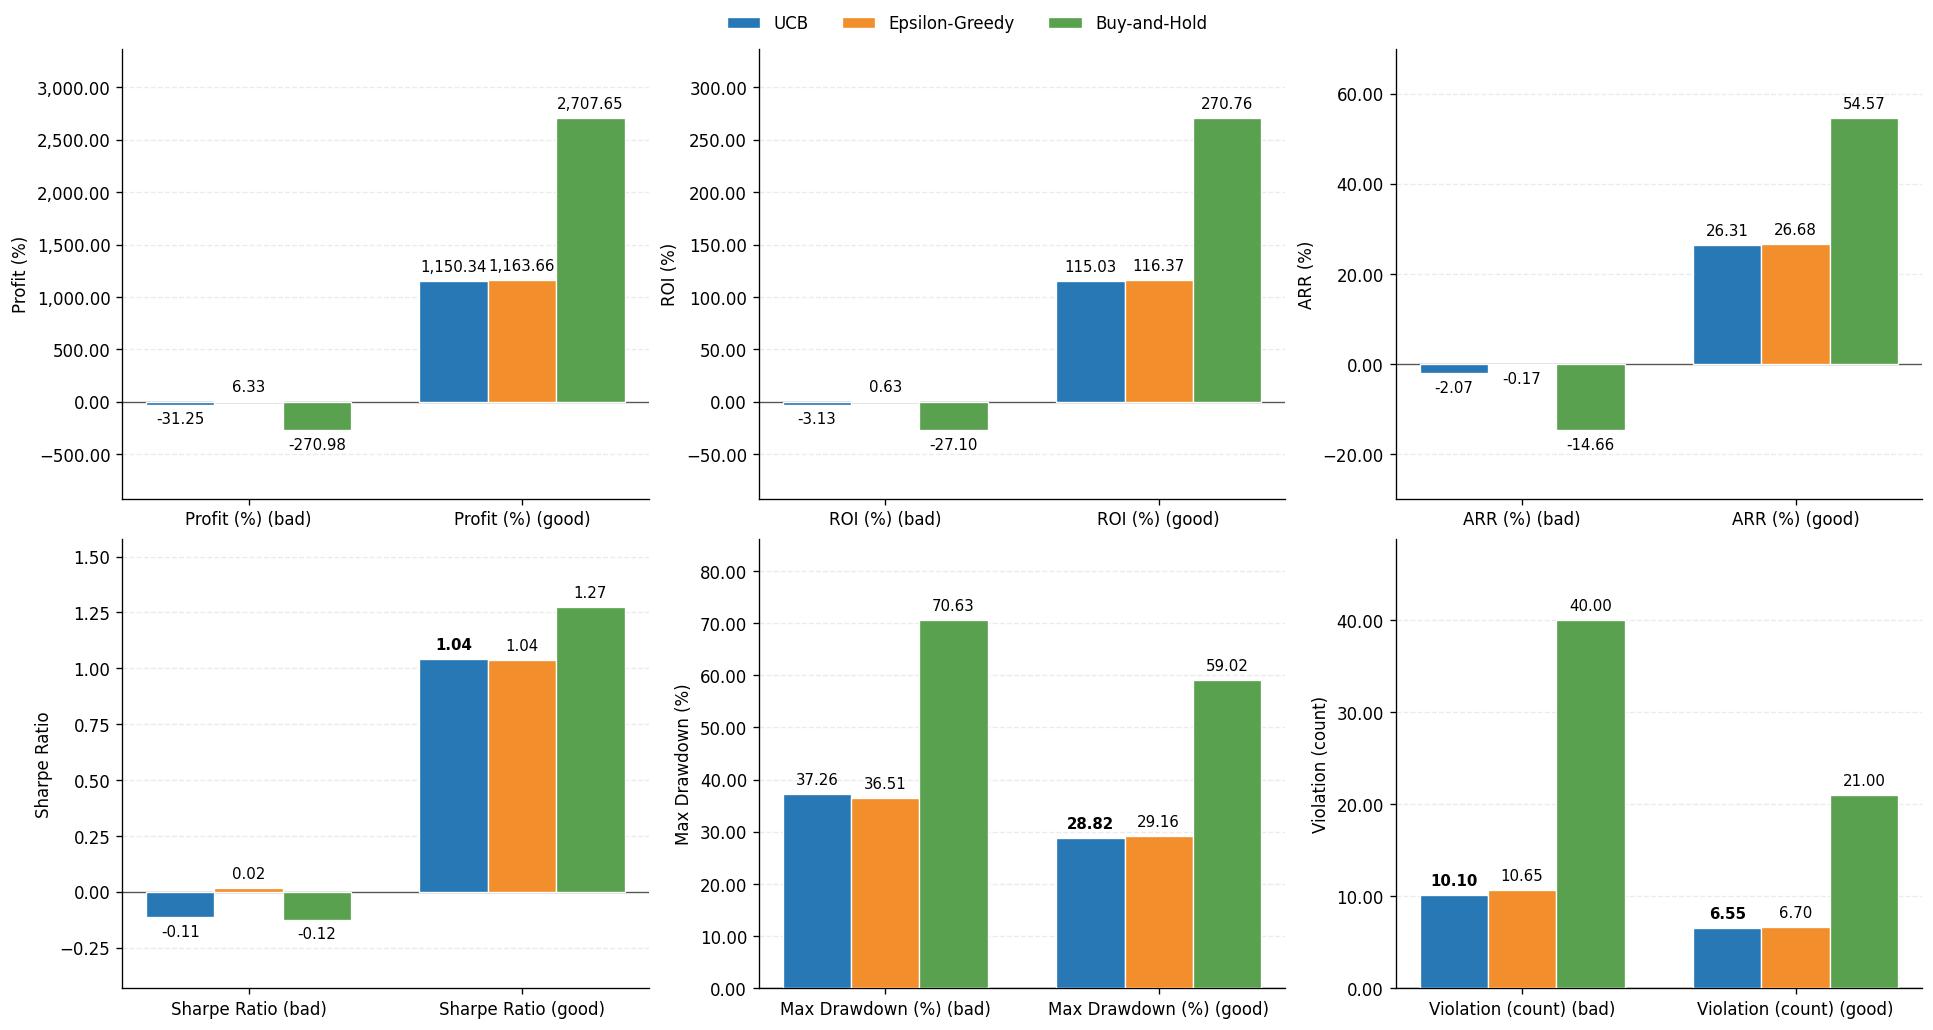

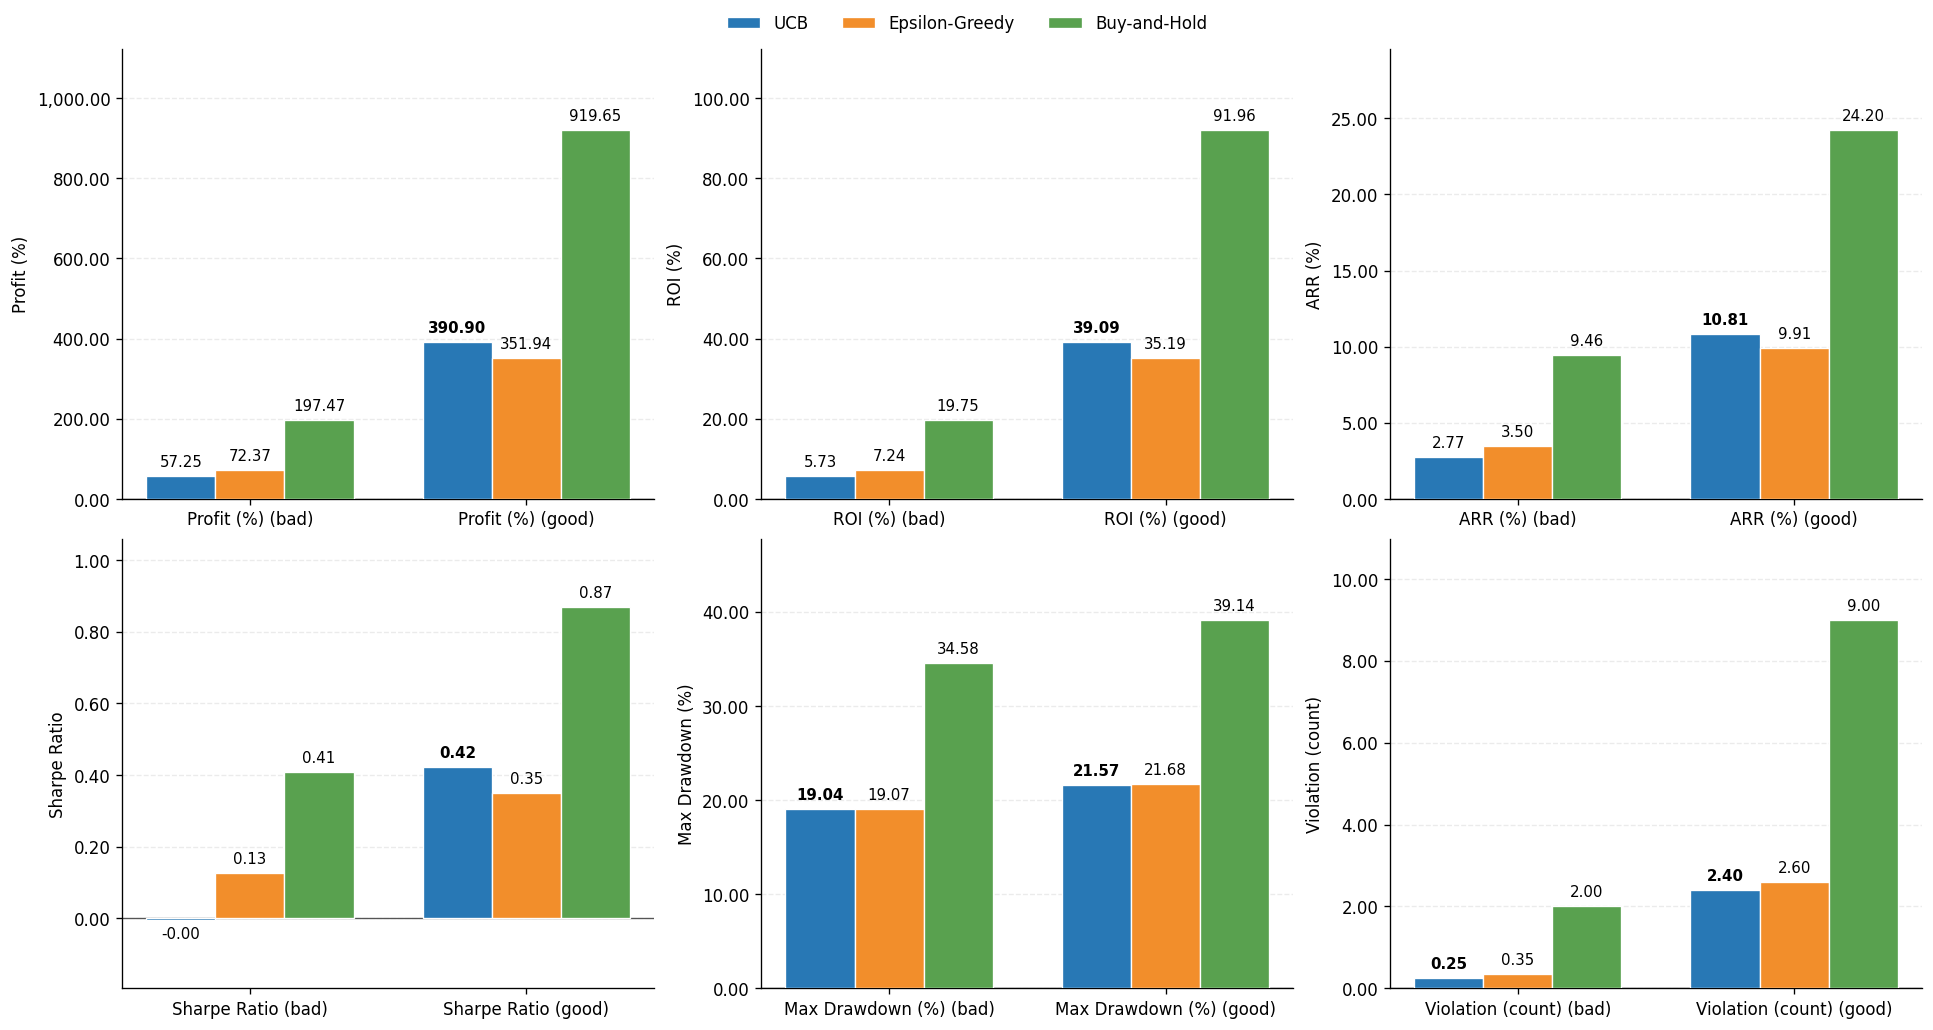

In [3]:
# Cột dữ liệu, nhãn đầy đủ và chiều so sánh (True: càng lớn càng tốt).
METRICS = (
    ('test_profit_mean', 'Profit (%)', True),
    ('test_roi_mean', 'ROI (%)', True),
    ('test_arr_mean', 'ARR (%)', True),
    ('test_sharpe_mean', 'Sharpe Ratio', True),
    ('test_max_drawdown_mean', 'Max Drawdown (%)', False),
    ('test_violations_mean', 'Violation (count)', False),
)
UCB_KEY = 'UNCERTAINTY_AWARE_UCB_009'
EPSILON_KEY = 'EPSILON_GREEDY'
BUY_AND_HOLD_KEY = 'BUY_AND_HOLD'
MODEL_KEYS = (UCB_KEY, EPSILON_KEY, BUY_AND_HOLD_KEY)
MODEL_LABELS = ('UCB', 'Epsilon-Greedy', 'Buy-and-Hold')
MODEL_COLORS = ('#2878B5', '#F28E2B', '#59A14F')

required_columns = {'_ticker', '_scenario', 'model_key'} | {item[0] for item in METRICS}
missing_columns = required_columns - set(experiment_results.columns)
if missing_columns:
    raise KeyError(f'Thiếu các cột bắt buộc: {sorted(missing_columns)}')


def annotate_bar(ax, bar, value, bold=False):
    """Ghi giá trị lên cột; UCB thắng baseline được in đậm."""
    if not np.isfinite(value):
        return
    offset = 4 if value >= 0 else -4
    ax.annotate(
        f'{value:,.2f}',
        (bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, offset),
        textcoords='offset points',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=9,
        fontweight='bold' if bold else 'normal',
        clip_on=False,
    )


for ticker in TICKERS:
    ticker_data = experiment_results.loc[experiment_results['_ticker'].eq(ticker)]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), constrained_layout=True)

    for ax, (column, label, higher_is_better) in zip(axes.flat, METRICS):
        values = np.full((len(SCENARIOS), len(MODEL_KEYS)), np.nan)
        for scenario_index, scenario in enumerate(SCENARIOS):
            rows = (
                ticker_data.loc[ticker_data['_scenario'].eq(scenario)]
                .drop_duplicates('model_key', keep='last')
                .set_index('model_key')
                .reindex(MODEL_KEYS)
            )
            values[scenario_index] = pd.to_numeric(rows[column], errors='coerce').to_numpy()

        x = np.arange(len(SCENARIOS), dtype=float)
        width = 0.25
        bars_by_model = []
        for model_index, (model_label, color) in enumerate(zip(MODEL_LABELS, MODEL_COLORS)):
            positions = x + (model_index - (len(MODEL_KEYS) - 1) / 2) * width
            bars = ax.bar(
                positions, values[:, model_index], width,
                label=model_label, color=color, edgecolor='white', linewidth=0.8, zorder=3,
            )
            bars_by_model.append(bars)

        for scenario_index in range(len(SCENARIOS)):
            ucb_value = values[scenario_index, 0]
            epsilon_value = values[scenario_index, 1]
            ucb_is_better = (
                np.isfinite(ucb_value) and np.isfinite(epsilon_value) and
                (ucb_value > epsilon_value if higher_is_better else ucb_value < epsilon_value)
            )
            for model_index, model_value in enumerate(values[scenario_index]):
                annotate_bar(
                    ax, bars_by_model[model_index][scenario_index], model_value,
                    bold=(model_index == 0 and ucb_is_better),
                )

        ax.set_ylabel(label)
        ax.set_xticks(x, [f'{label} ({scenario})' for scenario in SCENARIOS])
        ax.axhline(0, color='#555555', linewidth=0.8, zorder=2)
        ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
        ax.margins(y=0.22)

    # Một chú giải dùng chung; không đặt tựa đề theo yêu cầu.
    handles, legend_labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc='outside upper center', ncol=3, frameon=False)
    plt.show()

Liệt kê bảng kết quả cho toàn bộ các ticket. Có nhấn mạnh các UCB cao hơn.

In [ ]:
from IPython.display import display

# Lấy đúng cặp Mean/Std của 6 metrics đã dùng trong biểu đồ.
METRIC_STAT_COLUMNS = []
for mean_column, _, _ in METRICS:
    METRIC_STAT_COLUMNS.extend([mean_column, mean_column.replace('_mean', '_std')])

base_columns = ['_ticker', '_scenario', 'model_key']
required_stat_columns = set(base_columns + METRIC_STAT_COLUMNS)
missing_stat_columns = required_stat_columns - set(experiment_results.columns)
if missing_stat_columns:
    raise KeyError(f'Thiếu các cột thống kê bắt buộc: {sorted(missing_stat_columns)}')

statistics_rows = experiment_results.loc[:, base_columns + METRIC_STAT_COLUMNS].copy()
duplicate_mask = statistics_rows.duplicated(
    ['_ticker', '_scenario', 'model_key'], keep=False
)
if duplicate_mask.any():
    duplicated_keys = (
        statistics_rows.loc[
            duplicate_mask, ['_ticker', '_scenario', 'model_key']
        ]
        .drop_duplicates()
        .to_dict('records')
    )
    raise ValueError(
        f'Mỗi ticker/scenario/model phải có đúng một summary, bị trùng: {duplicated_keys}'
    )

expected_rows = len(TICKERS) * len(SCENARIOS) * len(MODEL_KEYS)
if len(statistics_rows) != expected_rows:
    raise ValueError(
        f'Bảng phải có {expected_rows} dòng nhưng nhận được {len(statistics_rows)} dòng.'
    )

for column in METRIC_STAT_COLUMNS:
    statistics_rows[column] = pd.to_numeric(statistics_rows[column], errors='raise')

ticker_order = {ticker: position for position, ticker in enumerate(TICKERS)}
model_labels = dict(zip(MODEL_KEYS, MODEL_LABELS))


def format_experiment_table(scenario, model_key):
    """Một bảng gồm 6 ticker cho một scenario và một chiến lược."""
    selected_rows = statistics_rows.loc[
        statistics_rows['_scenario'].eq(scenario),
        ['_ticker', 'model_key', *METRIC_STAT_COLUMNS],
    ]
    selected_rows = (
        selected_rows.loc[selected_rows['model_key'].eq(model_key)]
        .assign(_ticker_order=lambda frame: frame['_ticker'].map(ticker_order))
        .sort_values('_ticker_order')
        .reset_index(drop=True)
    )

    if len(selected_rows) != len(TICKERS):
        raise ValueError(
            f'{scenario}/{model_key}: cần {len(TICKERS)} ticker, '
            f'nhận được {len(selected_rows)}.'
        )

    output = pd.DataFrame({'Tên cổ phiếu': selected_rows['_ticker']})
    for mean_column, metric_label, _ in METRICS:
        std_column = mean_column.replace('_mean', '_std')
        means = selected_rows[mean_column].to_numpy(dtype=float)
        stds = selected_rows[std_column].to_numpy(dtype=float)
        output[metric_label] = [
            f'{mean:.2f} ± {std:.2f}'
            if np.isfinite(mean) and np.isfinite(std) else 'N/A'
            for mean, std in zip(means, stds)
        ]

    return output


# Sáu bảng: 2 scenario × 3 chiến lược; mỗi bảng có cùng 7 cột.
experiment_statistics_tables = {
    (scenario, model_key): format_experiment_table(scenario, model_key)
    for scenario in SCENARIOS
    for model_key in MODEL_KEYS
}

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    table_number = 1
    for scenario in SCENARIOS:
        print(f'===== Scenario: {scenario.upper()} =====')
        for model_key in MODEL_KEYS:
            print(f'Bảng {table_number}: {model_labels[model_key]}')
            display(experiment_statistics_tables[(scenario, model_key)])
            print()
            table_number += 1

# Nếu cần lưu riêng 6 bảng ra CSV, bỏ dấu # ở bốn dòng dưới:
# for (scenario, model_key), table in experiment_statistics_tables.items():
#     model_name = model_labels[model_key].lower().replace('-', '_').replace(' ', '_')
#     output_name = f'experiment_statistics_{scenario}_{model_name}.csv'
#     table.to_csv(output_name, index=False, encoding='utf-8-sig')
